# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [3]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [4]:
instrument_id = '511090'
trade_ymd = '20260319'
train_preset = 'volatility_16d'  # 可选: 'recent_6d', 'volatility_8d', 'volatility_12d', 'volatility_16d'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': f'delta_v1_adaptive_{train_preset}',
    'stride': 1,

    'short_window': 300,
    'long_window': 600,
    'y_window': 600,

    'open_threshold': 3,  
    'open_confidence': 0,  

    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 600,
    
    'k_up': 3,
    'k_down': 3,
    "stop_tighten_start": 6000,
    'stop_tighten_step' : 60,
    'stop_tighten_factor': 0.9,
    'stop_tighten_floor': 0.75,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [138]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 旧训练方式保留注释，不再直接使用：
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)
# train_dates, valid_dates, test_dates = split_dates_by_range(
#     trade_dates,
#     train_start="20250901",
#     train_end="20260228",
#     valid_start="20251201",
#     valid_end="20251201",
#     test_start="20260301",
#     test_end="20261231",
# )
# 上面这种写法容易让验证集与训练集重叠，后面也容易误把测试集当验证集。

train_candidate_dates, _, _ = split_dates_by_range(
    trade_dates,
    train_start="20250901",
    train_end="20260423",
)

_, valid_dates, _ = split_dates_by_range(
    trade_dates,
    valid_start="20260101",
    valid_end="20260423",
)

_, _, test_dates = split_dates_by_range(
    trade_dates,
    test_start="20260401",
    test_end="20260401",
)

train_dates = select_train_dates_by_preset(
    train_preset,
    train_candidate_dates,
    instrument_id=instrument_id,
)

print(f"当前训练方案: {train_preset}")
print(f"最终训练天数: {len(train_dates)}")
print("训练日期列表:", train_dates)


总交易日数量: 79
交易日范围: 20250901 ~ 20260423
训练集: 20250901 ~ 20260423 (79天)
验证集: 无
测试集: 无
训练集: 无
验证集: 20260105 ~ 20260423 (37天)
测试集: 无
训练集: 无
验证集: 无
测试集: 20260401 ~ 20260401 (1天)
当前训练方案: volatility_16d
最终训练天数: 16
训练日期列表: ['20250911', '20251009', '20251021', '20251103', '20251105', '20251113', '20251121', '20251205', '20251225', '20251229', '20260109', '20260115', '20260123', '20260205', '20260323', '20260325']


## 生成训练数据

In [139]:
# 旧方式保留注释，不再分别调用 samples_from_dates：
# X_train, y_train, feature_names = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
# X_valid, y_valid, _ = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
# X_test, y_test, _ = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)

all_dates = sorted(set(train_dates) | set(valid_dates) | set(test_dates))
sample_cache = load_daily_sample_cache(
    all_dates,
    instrument_id,
    param_dict,
    create_feature,
    create_y,
)

X_train, y_train, feature_names = concat_sample_cache(sample_cache, train_dates)
X_valid, y_valid, _ = concat_sample_cache(sample_cache, valid_dates)
X_test, y_test, _ = concat_sample_cache(sample_cache, test_dates)

print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

20250911: 产生 243 个样本
20251009: 产生 279 个样本
20251021: 产生 296 个样本
20251103: 产生 288 个样本
20251105: 产生 282 个样本
20251113: 产生 288 个样本
20251121: 产生 276 个样本
20251205: 产生 275 个样本
20251225: 产生 340 个样本
20251229: 产生 261 个样本
20260105: 产生 308 个样本
20260107: 产生 286 个样本
20260109: 产生 275 个样本
20260113: 产生 273 个样本
20260115: 产生 305 个样本
20260119: 产生 324 个样本
20260121: 产生 268 个样本
20260123: 产生 285 个样本
20260127: 产生 303 个样本
20260129: 产生 327 个样本
20260203: 产生 319 个样本
20260205: 产生 345 个样本
20260209: 产生 340 个样本
20260211: 产生 346 个样本
20260213: 产生 310 个样本
20260225: 产生 306 个样本
20260227: 产生 382 个样本
20260303: 产生 331 个样本
20260305: 产生 363 个样本
20260309: 产生 316 个样本
20260311: 产生 331 个样本
20260313: 产生 333 个样本
20260317: 产生 339 个样本
20260319: 产生 307 个样本
20260323: 产生 321 个样本
20260325: 产生 369 个样本
20260327: 产生 375 个样本
20260331: 产生 342 个样本
20260401: 产生 356 个样本
20260403: 产生 364 个样本
20260407: 产生 330 个样本
20260409: 产生 379 个样本
20260413: 产生 357 个样本
20260415: 产生 352 个样本
20260417: 产生 320 个样本
20260421: 产生 302 个样本
20260423: 产生 295 个样本
训练集样本: X=(472

In [140]:
# 不再单独生成验证集样本，上一格已经通过 sample_cache 一次性完成。
pd.Series(y_train).value_counts().rename('train_label_count')

0    3289
1    1439
Name: train_label_count, dtype: int64

In [141]:
pd.Series(y_valid).value_counts().rename('valid_label_count')

0    8440
1    3644
Name: valid_label_count, dtype: int64

In [142]:
# 旧代码如下，已禁用：
# X_valid = X_test
# y_valid = y_test
# 不要再把测试集当验证集用，这会污染阈值优化和模型选择。

pd.Series(y_test).value_counts().rename('test_label_count')

0    264
1     92
Name: test_label_count, dtype: int64

## 训练模型

In [143]:
print(f"开始训练，方案: {train_preset}")
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

开始训练，方案: volatility_16d
训练 xgboost 模型...
[0]	validation_0-logloss:0.69295


[100]	validation_0-logloss:0.67528
[200]	validation_0-logloss:0.66947
[300]	validation_0-logloss:0.66756
[400]	validation_0-logloss:0.66584
[500]	validation_0-logloss:0.66405
[600]	validation_0-logloss:0.66285
[700]	validation_0-logloss:0.66092
[799]	validation_0-logloss:0.65954
阈值优化完成: Best Threshold=0.5519, F0.5=0.4575

特征重要性（前10个）:
volatility    0.186601
WAMP          0.099178
alpha_06      0.092707
alpha_04      0.081584
alpha_07      0.075687
num_trades    0.068956
alpha_01      0.067039
volume        0.066891
alpha_03      0.066858
alpha_02      0.066117
dtype: float32

XGBoost特征重要性详情:

Gain重要性排名:
       feature       gain
1   volatility  27.431692
3         WAMP  14.579937
10    alpha_06  13.628599
8     alpha_04  11.993423
11    alpha_07  11.126606
0   num_trades  10.137093
5     alpha_01   9.855264
4       volume   9.833534
7     alpha_03   9.828571
6     alpha_02   9.719702
2       spread   9.612255
9     alpha_05   9.260821

Weight重要性排名:
       feature  weight
3         WAMP

In [144]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_{train_preset}.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_511090_volatility_16d.pkl


## 测试模型

测试集准确率: 0.6517

分类报告:
              precision    recall  f1-score   support

           0       0.79      0.72      0.75       264
           1       0.36      0.45      0.40        92

    accuracy                           0.65       356
   macro avg       0.57      0.58      0.58       356
weighted avg       0.68      0.65      0.66       356


PR曲线AUC: 0.3362
平均精度 (AP): 0.3436

预测概率统计:
  均值: 0.4935
  标准差: 0.1092
  最小值: 0.2167
  25%分位数: 0.4232
  中位数: 0.5030
  75%分位数: 0.5709
  最大值: 0.7400

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.4791, 标准差=0.1139
  标签1 (正类): 均值=0.5347, 标准差=0.0816


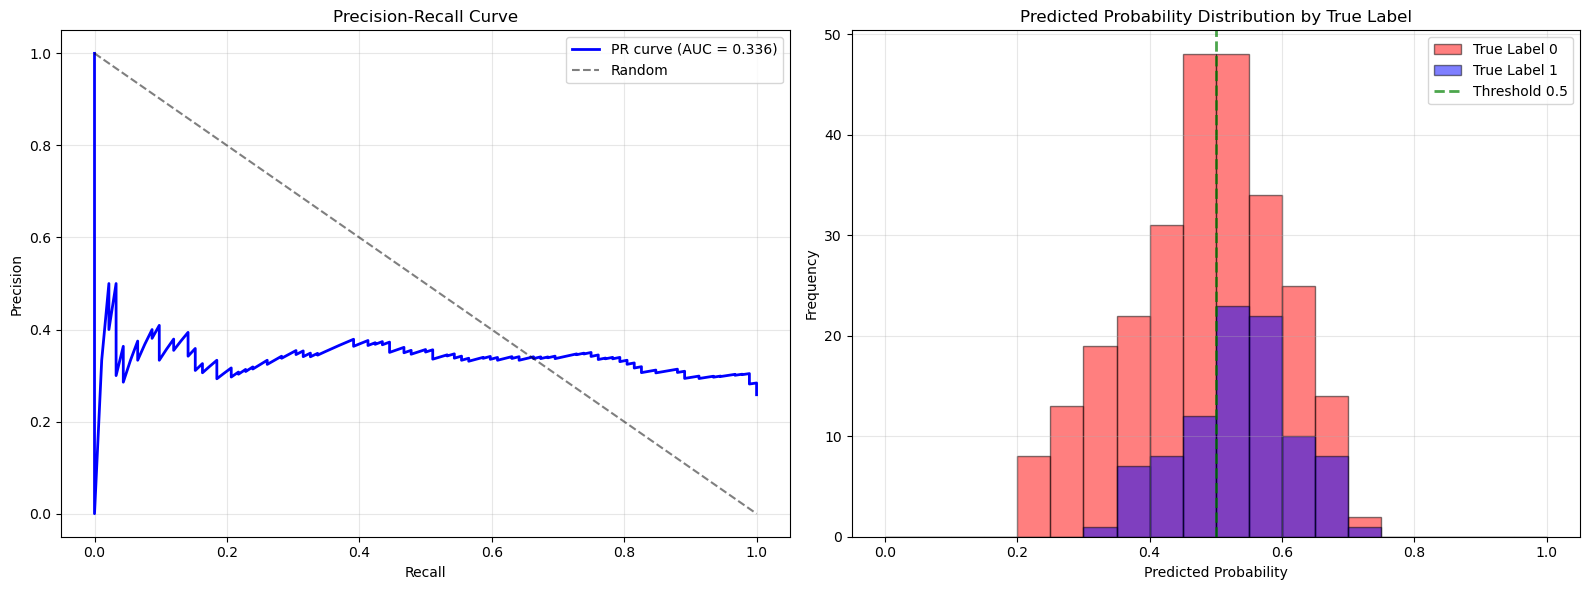

In [145]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

## 创建策略实例

In [5]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_{train_preset}.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive_volatility_16d


## 使用backtesting工具进行回测

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 79 个有数据的交易日
-> 过滤后剩余 79 个有数据的交易日
-> 过滤掉 651 个无数据日期: ['20250101', '20250102', '20250103', '20250104', '20250105', '20250106', '20250107', '20250108', '20250109', '20250110']...
-> 回测标的: 511090 (20250101 - 20261231)
-> 任务分配: 共 79 天，使用 4 个核心并行计算...


[SpawnPoolWorker-84] 日期 20260305 完成 | 盈亏: 7.10 | 成交: 12次 | 胜率: 50.0% | 平均持仓: 872.3快照
[SpawnPoolWorker-81] 日期 20251103 完成 | 盈亏: -1.40 | 成交: 14次 | 胜率: 21.4% | 平均持仓: 694.9快照
[SpawnPoolWorker-83] 日期 20251229 完成 | 盈亏: 0.70 | 成交: 8次 | 胜率: 25.0% | 平均持仓: 764.1快照
[SpawnPoolWorker-82] 日期 20250901 完成 | 盈亏: 16.90 | 成交: 5次 | 胜率: 60.0% | 平均持仓: 1393.8快照
[SpawnPoolWorker-84] 日期 20260309 完成 | 盈亏: 36.20 | 成交: 4次 | 胜率: 75.0% | 平均持仓: 1464.5快照
[SpawnPoolWorker-81] 日期 20251105 完成 | 盈亏: 10.50 | 成交: 10次 | 胜率: 50.0% | 平均持仓: 970.3快照
[SpawnPoolWorker-83] 日期 20251231 完成 | 盈亏: 9.40 | 成交: 7次 | 胜率: 42.9% | 平均持仓: 733.4快照
[SpawnPoolWorker-82] 日期 20250903 完成 | 盈亏: 45.50 | 成交: 5次 | 胜率: 100.0% | 平均持仓: 1287.4快照
[SpawnPoolWorker-84] 日期 20260311 完成 | 盈亏: 15.10 | 成交: 10次 | 胜率: 60.0% | 平均持仓: 977.2快照
[SpawnPoolWorker-81] 日期 20251107 完成 | 盈亏: 21.50 | 成交: 6次 | 胜率: 100.0% | 平均持仓: 1262.8快照
[SpawnPoolWorker-83] 日期 20260105 完成 | 盈亏: 2.60 | 成交: 9次 | 胜率: 66.7% | 平均持仓: 911.8快照
[SpawnPoolWorker-82] 日期 20250905 完成 | 盈亏: 46.40 | 成交: 1次 | 

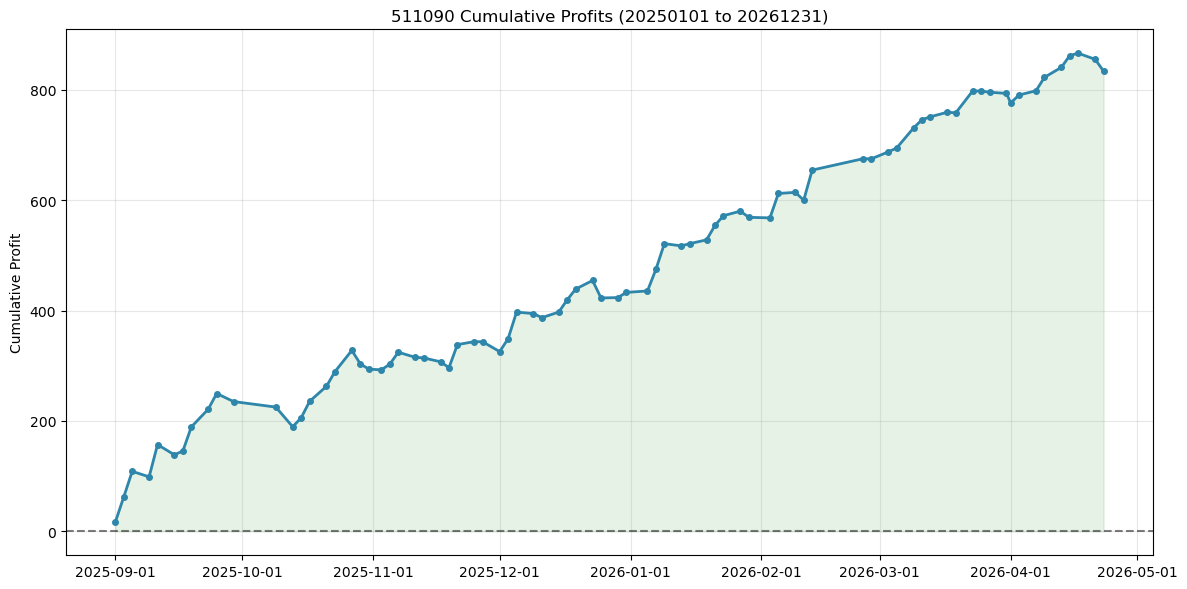


并行回测结果汇总:
{'测试天数': 79, '累计总盈亏': np.float64(833.9), '总成交次数': 786, '盈利交易次数': 322, '亏损交易次数': 464, '加权每手胜率%': np.float64(40.97), '日均盈亏': np.float64(10.56), '胜率(天)%': 63.29, '盈亏比(日均)': np.float64(2.13), '最大单日盈利': 58.4, '最大单日亏损': -35.6, '每笔交易平均盈利': np.float64(1.06), '加权平均持仓时间(快照)': np.float64(814.7)}


In [150]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20250101",
    end_ymd="20261231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4,
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)

/home/jovyan/work/backtest_result/511090_20250901_delta_v1_adaptive_volatility_16d.pkl 已请求
日期 20250901 完成，盈亏: 16.20, 成交: 10次, 胜率: 0.0%, 平均持仓: 0.0快照
511090_20250902 no data
日期 20250902 无数据，跳过
/home/jovyan/work/backtest_result/511090_20250903_delta_v1_adaptive_volatility_16d.pkl 已请求
日期 20250903 完成，盈亏: 45.00, 成交: 10次, 胜率: 0.0%, 平均持仓: 0.0快照
511090_20250904 no data
日期 20250904 无数据，跳过
/home/jovyan/work/backtest_result/511090_20250905_delta_v1_adaptive_volatility_16d.pkl 已请求
日期 20250905 完成，盈亏: 47.10, 成交: 2次, 胜率: 0.0%, 平均持仓: 0.0快照
511090_20250906 no data
日期 20250906 无数据，跳过
511090_20250907 no data
日期 20250907 无数据，跳过
511090_20250908 no data
日期 20250908 无数据，跳过
/home/jovyan/work/backtest_result/511090_20250909_delta_v1_adaptive_volatility_16d.pkl 已请求
日期 20250909 完成，盈亏: -5.80, 成交: 10次, 胜率: 0.0%, 平均持仓: 0.0快照
511090_20250910 no data
日期 20250910 无数据，跳过
/home/jovyan/work/backtest_result/511090_20250911_delta_v1_adaptive_volatility_16d.pkl 已请求
日期 20250911 完成，盈亏: 58.10, 成交: 6次, 胜率: 0.0%, 平均持仓: 0.0快照
5110

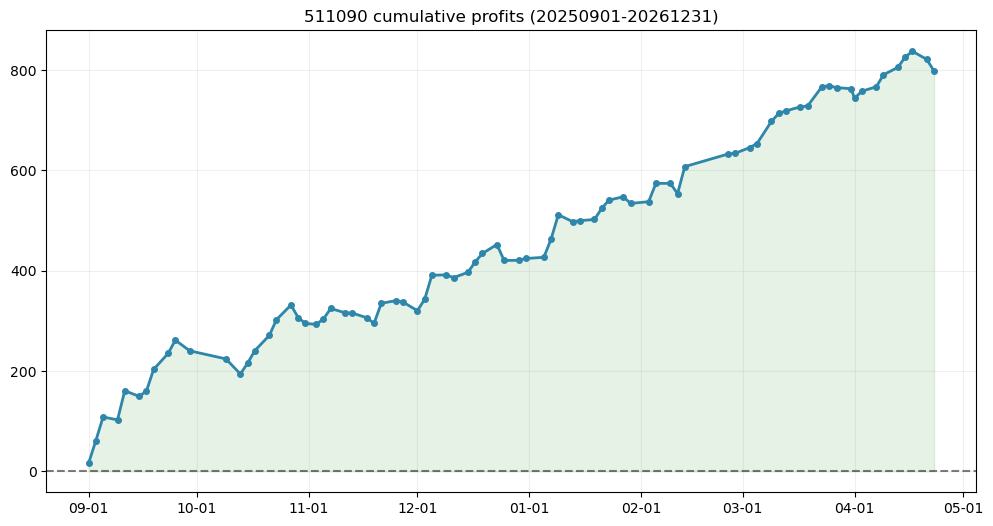


多日回测结果汇总:
{'测试天数': 79, '累计总盈亏': np.float64(797.8), '总成交次数': 1618, '盈利交易次数': 0, '亏损交易次数': 0, '加权每手胜率%': np.float64(0.0), '日均盈亏': np.float64(10.1), '胜率(天)%': 69.62, '盈亏比(日均)': np.float64(1.52), '最大单日盈利': 58.1, '最大单日亏损': -31.8, '每笔交易平均盈利': np.float64(0.0), '加权平均持仓时间(快照)': np.float64(0.0)}


In [7]:
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
from multi_day_backtest import backtest_multi_days
multi_day_result = backtest_multi_days(
    instrument_id=instrument_id,
    start_ymd="20250901",
    end_ymd="20260423",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    official=True,
)
summary = backtest_summary(multi_day_result)
print("\n多日回测结果汇总:")
print(summary)

## 延迟回测结果

In [ ]:
from delay_stability_test import batch_delay_stability_test
batch_delay_stability_test(
    instrument_id,
    "20251201",
    "20251231",
    StrategyDemo,
    model_path,
    param_dict,
    [0,1,2,4,8,16,32,64,128,256,512,1024],
    
)

## 保存回测结果

In [151]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/backtest_result/511090_delta_v1_adaptive_volatility_16d_20260425_131857
回测结果已保存到: /home/jovyan/work/tactics_demo/backtest_result/511090_delta_v1_adaptive_volatility_16d_20260425_131857
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [362]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("511520", "20260420", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260420_062243

总共删除了 1 个文件夹


## 单日回测观察

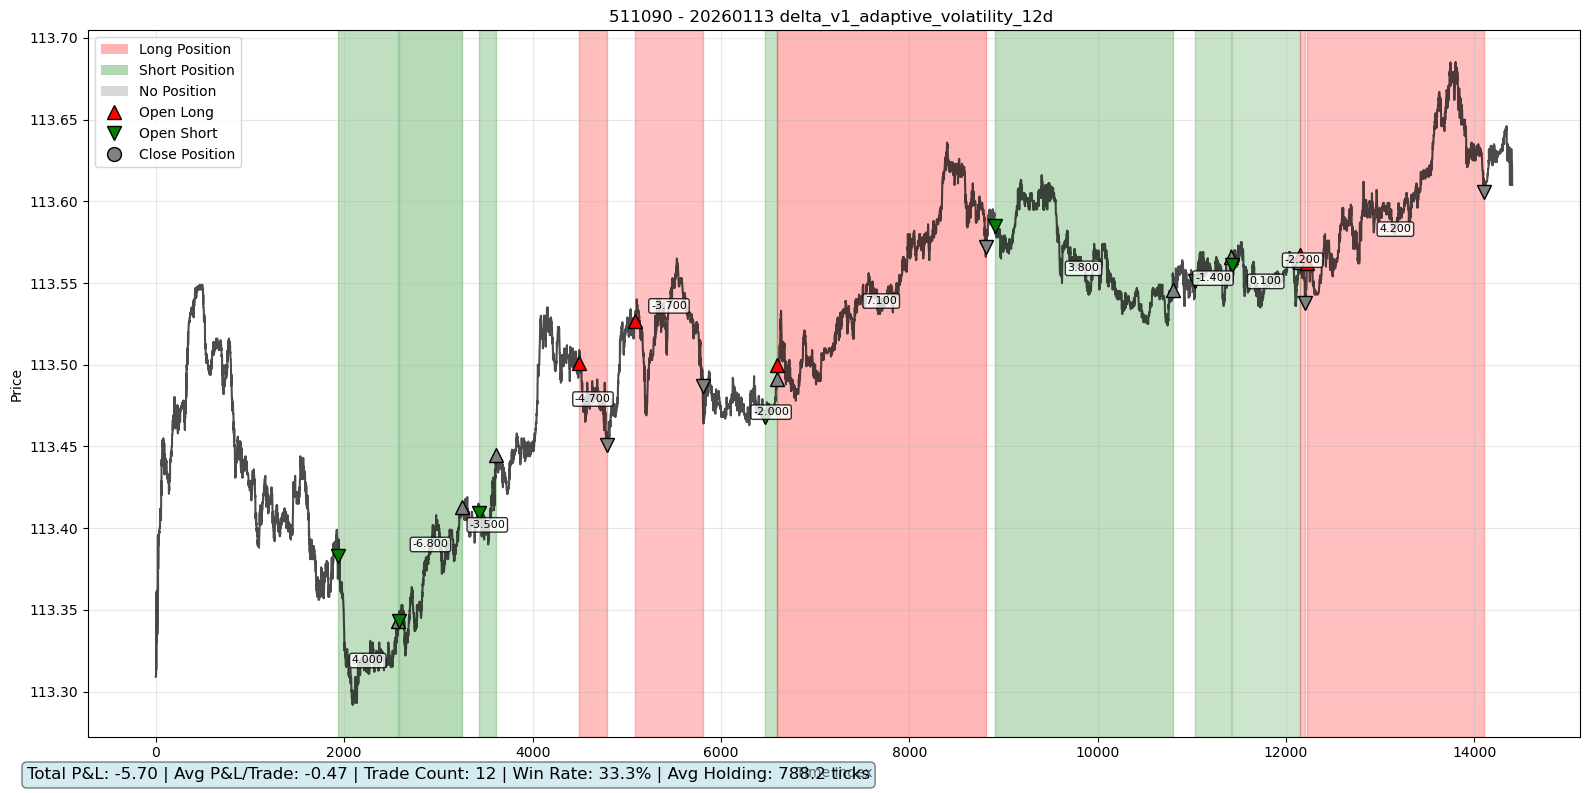

In [84]:
from single_day_backtest import single_day_backtest,plot_delta_history
strategy = StrategyDemo(model_path, param_dict)
hh = single_day_backtest(instrument_id,'20260113',StrategyDemo,model_path,param_dict,official = False)

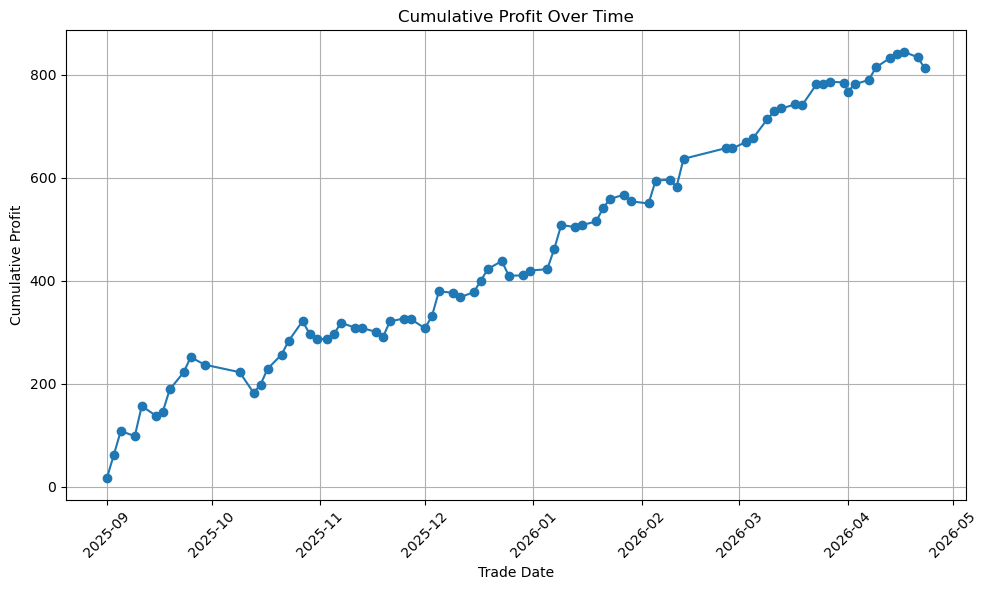

In [148]:
summary = pd.read_csv('/home/jovyan/work/tactics_demo/backtest_result/511090_delta_v1_adaptive_volatility_16d_20260425_130210/daily_results.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
summary['trade_ymd'] = pd.to_datetime(summary['trade_ymd'], format='%Y%m%d')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
